## 0. Environment Setup and Installations

In [ ]:
# 1. Mount Google Drive to access your files
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.7 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


#1. copy images from drive

In [ ]:
import os
import shutil
import time
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

src_dir = '/content/drive/MyDrive/Deepfake_Project/Balanced_Dataset_V2_RetinaFace'
dest_dir = '/content/Balanced_Dataset_V2_RetinaFace'

print("Scanning files in Drive (this takes a minute)...")
files_to_copy = []

# Scanning the drive and building the folder structure at the destination
for root, dirs, files in os.walk(src_dir):
    dest_path = root.replace(src_dir, dest_dir)
    os.makedirs(dest_path, exist_ok=True)
    for file in files:
        files_to_copy.append(os.path.join(root, file))

print(f"Found {len(files_to_copy)} files. Starting parallel copy...")

# Copy function (skips already copied files in case of interruption)
def copy_file(file_path, max_retries=3):
    dest_path = file_path.replace(src_dir, dest_dir)
    if not os.path.exists(dest_path): #check if the file was already (in case of a crash)
        for attempt in range(max_retries):
            try:
                shutil.copy2(file_path, dest_path)
                return # successfull copy
            except FileNotFoundError as e:
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt) #sleep between tries
                else:
                    print(f"\nFailed to copy {file_path} after {max_retries} attempts.")
                    raise e # crush only if the tries have played

# multi threading to copy files simultaneously
with ThreadPoolExecutor(max_workers=16) as executor:
    list(tqdm(executor.map(copy_file, files_to_copy), total=len(files_to_copy)))

print("Copy completed successfully!")

Scanning files in Drive (this takes a minute)...
Found 159968 files. Starting parallel copy...


  0%|          | 0/159968 [00:00<?, ?it/s]

Copy completed successfully!


# 11. Initilaize Model with Tuned DFDC Weights

In [ ]:
# --- Model Initialization + Load Fine-Tuned Weights ---

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- Load Fine-Tuned Q-Former Weights ---
weights_path = "/content/drive/MyDrive/Deepfake_Project/DFDC_Weights/qformer_finetuned_DFDC.pth"

print(f" Loading Q-Former weights from {weights_path}...")
checkpoint = torch.load(weights_path, map_location=device)

# Load the fine tuned weights into the Q-former
model.qformer.load_state_dict(checkpoint)
print(" Q-Former weights loaded successfully!")

# --- Freeze everything for Inference ---
# the model just evaluates
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("Model ready for evaluation!")

 Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

 Loading Q-Former weights from /content/drive/MyDrive/Deepfake_Project/DFDC_Weights/qformer_finetuned_DFDC.pth...
 Q-Former weights loaded successfully!
Model ready for evaluation!


# 12. Dataset Loading

In [ ]:
import os
import glob
import json
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

# Custom Dataset class inheriting from PyTorch Dataset
class PreExtractedDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        label_str = row['label']  # Expected: "Yes" (Real) or "No" (Fake)

        # Load image and set the exact prompt from the methodology
        image = Image.open(image_path).convert('RGB')
        prompt = "is this photo real?"

        # Process ONLY the base prompt and image
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # Pass the plain text label directly to the batch dictionary for evaluation
        inputs['text_label'] = label_str
        return inputs

# --- Paths ---
base_dir = '/content/Balanced_Dataset_V2_RetinaFace'
fake_images_folder = os.path.join(base_dir, 'Fake')
real_images_folder = os.path.join(base_dir, 'Real')

# Load train video IDs to exclude from test set
with open('/content/drive/MyDrive/Deepfake_Project/train_video_ids.json', 'r') as f:
    train_video_ids = set(json.load(f))
print(f"Loaded {len(train_video_ids)} train video IDs to exclude.")

all_paths = []
all_labels = []

# Collect Fake images — exclude train video IDs
if os.path.exists(fake_images_folder):
    fake_paths = glob.glob(os.path.join(fake_images_folder, '**', '*.*'), recursive=True)
    fake_paths = [p for p in fake_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    fake_paths = [p for p in fake_paths if os.path.basename(os.path.dirname(p)) not in train_video_ids]
    all_paths.extend(fake_paths)
    all_labels.extend(["No"] * len(fake_paths))
    print(f"Fake images after filtering: {len(fake_paths)}")
else:
    print(f"Warning: Fake folder not found at {fake_images_folder}")

# Collect Real images — exclude train video IDs
if os.path.exists(real_images_folder):
    real_paths = glob.glob(os.path.join(real_images_folder, '**', '*.*'), recursive=True)
    real_paths = [p for p in real_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    real_paths = [p for p in real_paths if os.path.basename(os.path.dirname(p)) not in train_video_ids]
    all_paths.extend(real_paths)
    all_labels.extend(["Yes"] * len(real_paths))
    print(f"Real images after filtering: {len(real_paths)}")
else:
    print(f"Warning: Real folder not found at {real_images_folder}")

print(f"Total images after filtering train videos: {len(all_paths)}")

if len(all_paths) > 0:
    # Create DataFrame
    test_df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
    print(f"Testing images (Zero-Shot DF-v2): {len(test_df)}")

    # Create Dataset
    test_dataset = PreExtractedDeepfakeDataset(test_df, processor)

    # Calculate optimal workers
    optimal_workers = min(8, multiprocessing.cpu_count())

    # Create DataLoader
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=optimal_workers,
        pin_memory=True,
        prefetch_factor=2
    )
    print("test_dataloader created successfully!")
else:
    print("ERROR: No images loaded. Please verify the subfolder names inside /content/Balanced_Dataset_V2_RetinaFace")

Loaded 500 train video IDs to exclude.
Fake images after filtering: 134848
Real images after filtering: 10880
Total images after filtering train videos: 145728
Testing images (Zero-Shot DF-v2): 145728
test_dataloader created successfully!


#13. fine tuned Model 1st Evaluation

In [ ]:
# --- 4. Probabilistic Evaluation Loop + Embeddings Extraction ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

# Put the model in evaluation mode (turns off dropout and freezes weights)
model.eval()

# Lists to store the results of the entire test set
all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = []

# Define the target words we want the model to predict
# "Yes" means Real, "No" means Fake
yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]

# Convert these text words into model token IDs
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids  = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

# Move the token IDs to the GPU
yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("Starting Fine-Tuned Evaluation on DF-V2 Test Set...")

# Turn off gradient calculation to save memory and speed up inference
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):

        # Move all batch data to the GPU
        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Convert text labels ("Yes"/"No") into numbers (0 for Real, 1 for Fake)
        text_labels = batch['text_label']
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in text_labels])

        # ----------------- 1. Embeddings extraction ----------------------
        # Pass the image through the vision model and then the Q-Former
        # to extract the deep features (embeddings) of the image
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        # Average the tokens to get a single vector per image, then save it
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ------------------ 2. Probabilistic inference -------------------
        # Ask the model to generate only 1 single word (max_new_tokens=1)
        # and tell it to return the raw math scores (output_scores=True)
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        # Get the raw scores (logits) of the very first generated word
        first_token_logits = outputs.scores[0]

        # Extract only the scores belonging to the "Yes" and "No" tokens
        yes_logits = first_token_logits[:, yes_tensor].max(dim=-1).values
        no_logits  = first_token_logits[:, no_tensor].max(dim=-1).values

        # Combine them and convert the raw scores into percentages (0.0 to 1.0) using Softmax
        pair_logits = torch.stack([yes_logits, no_logits], dim=-1)
        pair_probs  = torch.softmax(pair_logits, dim=-1)

        # The probability of being "Fake" is the percentage score of the "No" token
        fake_probability = pair_probs[:, 1]

        # Save batch results to our main lists
        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ------------------------- Metrics & Saving --------------------------------
# Convert lists to NumPy arrays for easy math operations
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)

# Define the folder path and create it if it doesn't exist
save_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_DFDC'
os.makedirs(save_dir, exist_ok=True)

# Save the raw arrays so we can create graphs later without re-running the model
np.save(f'{save_dir}/finetuned_probs.npy', all_probs)
np.save(f'{save_dir}/finetuned_labels.npy', all_labels)
np.save(f'{save_dir}/finetuned_embeddings.npy', np.array(all_embeddings))
print(f"Saved to: {save_dir}")

# Calculate the main general metric (ROC-AUC)
auc_score = roc_auc_score(all_labels, all_probs)

# Find the absolute best threshold by checking all options from 0.10 to 0.90
thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc = accuracies[best_idx]

# Calculate advanced industry metrics using the best threshold we found
binary_preds = (all_probs >= best_thresh).astype(int)
f1 = f1_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)

# Print the final report
print(f"Optimal Threshold: {best_thresh:.2f} | AUC: {auc_score:.4f} | ACC: {best_acc*100:.2f}% | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

Starting Fine-Tuned Evaluation on DF-V2 Test Set...


Evaluating: 100%|██████████| 4554/4554 [25:20<00:00,  3.00it/s]


Saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_DFDC
Optimal Threshold: 0.10 | AUC: 0.6727 | ACC: 92.61% | F1: 0.9616 | Precision: 0.9271 | Recall: 0.9987


#14. Graphs for 1st Evaluation

Calculating Bootstrap Confidence Intervals (1000 iterations)...
Final ROC-AUC: 0.6727 (95% CI: [0.6674, 0.6788])


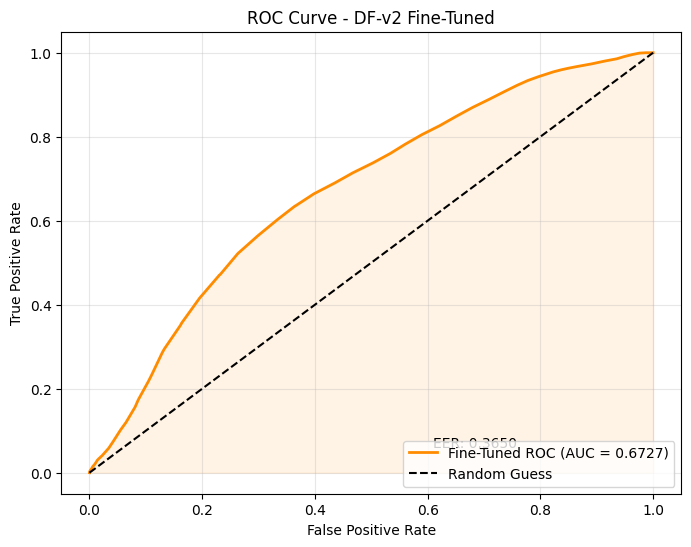

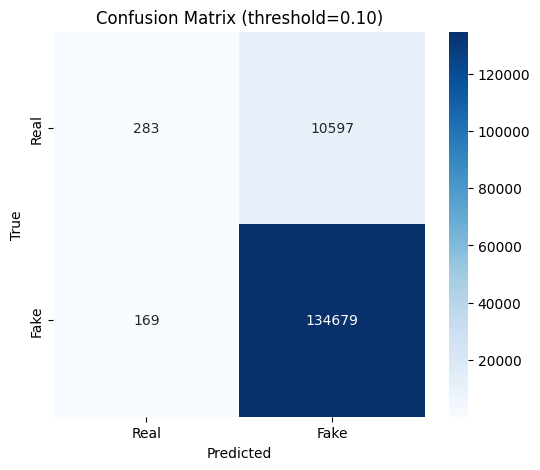

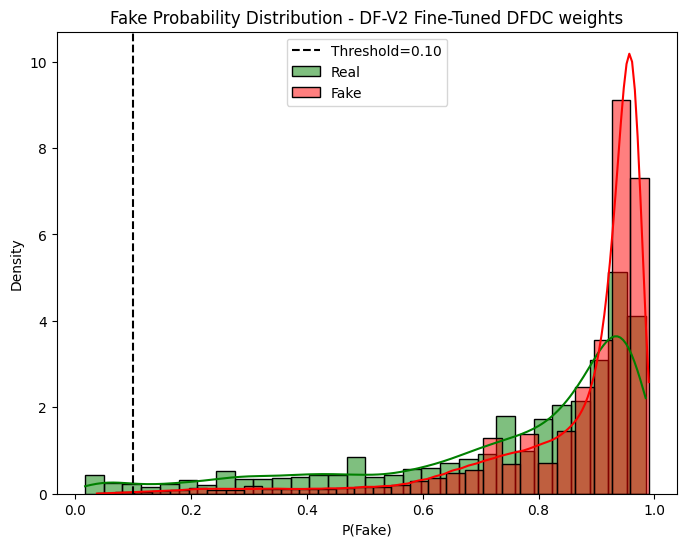

Generating t-SNE Visualization...
Silhouette Score: 0.2165


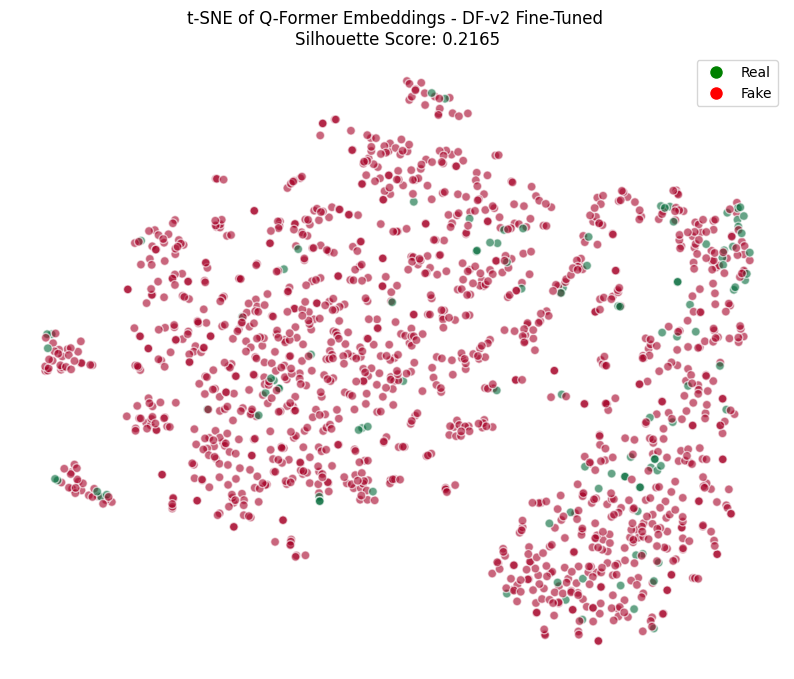

In [ ]:
# --- Advanced Metrics & Visualizations ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Configuration & Paths
# ---------------------------------------------------------
base_results_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_DFDC'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)

# Set random seed for reproducibility (especially for t-SNE and Bootstrapping)
rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
# We randomly sample our predictions with replacement 1000 times.
# This helps us prove that our AUC score is stable and not just a "lucky" result.
print("Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    # Randomly select indices with replacement
    indices = rng.randint(0, len(all_probs), len(all_probs))

    # Ensure both classes (Real/Fake) are present in the sample
    if len(np.unique(all_labels[indices])) < 2:
        continue

    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

# Sort the results to find the 2.5% and 97.5% percentiles (95% Confidence Interval)
sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve & EER
# ==========================================
# ROC Curve shows the tradeoff between True Positive Rate and False Positive Rate.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

# Calculate Equal Error Rate (EER)
# EER is the point where False Acceptance Rate equals False Rejection Rate.
# In biometric security, a lower EER means a better, more balanced system.
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Fine-Tuned ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add EER text inside the plot
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DF-v2 Fine-Tuned')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
# Shows exactly how many images were classified correctly or incorrectly
# based on our calculated 'best_thresh'.
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
# Visualizes the model's confidence. We want the green (Real) and red (Fake)
# distributions to be as far apart as possible.
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - DF-V2 Fine-Tuned DFDC weights')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("Generating t-SNE Visualization...")
# Sample up to 1500 embeddings to prevent the t-SNE calculation from taking too long
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

# Silhouette Score measures how similar an object is to its own cluster
# compared to other clusters. A score > 0 means the model successfully separated the classes.
sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# t-SNE reduces the high-dimensional Q-Former vectors into 2D points so we can plot them.
embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - DF-v2 Fine-Tuned \nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_finetuned.png'), dpi=300, bbox_inches='tight')

#15 Clean model for 2nd Evaluation

In [ ]:
import gc
import torch

# 1. Delete the model (and any other heavy variables if needed)
try:
    del model
except NameError:
    pass # In case the model was already deleted

# 2. Force Python's Garbage Collector to run
gc.collect()

# 3. Clear the PyTorch CUDA cache
torch.cuda.empty_cache()

print("Model deleted and GPU/RAM memory cleared.")

Model deleted and GPU/RAM memory cleared.


#16. Initilaize Model with Tuned Weights mid slow dfdc

In [ ]:
# --- Model Initialization + Load Fine-Tuned Weights ---

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- Load Fine-Tuned Q-Former Weights ---
weights_path = "/content/drive/MyDrive/Deepfake_Project/DFDC_Weights_slow_5e/qformer_finetuned_DFDC_slow_5e.pth"

print(f" Loading Q-Former weights from {weights_path}...")
checkpoint = torch.load(weights_path, map_location=device)

# Load the fine tuned weights into the Q-former
model.qformer.load_state_dict(checkpoint)
print(" Q-Former weights loaded successfully!")

# --- Freeze everything for Inference ---
# the model just evaluates
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("Model ready for evaluation!")

 Loading Processor...
 Loading Base Model in bfloat16...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

 Loading Q-Former weights from /content/drive/MyDrive/Deepfake_Project/DFDC_Weights_slow_5e/qformer_finetuned_DFDC_slow_5e.pth...
 Q-Former weights loaded successfully!
Model ready for evaluation!


#17. Dataset Loading

In [ ]:
import os
import glob
import json
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

# Custom Dataset class inheriting from PyTorch Dataset
class PreExtractedDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        label_str = row['label']  # Expected: "Yes" (Real) or "No" (Fake)

        # Load image and set the exact prompt from the methodology
        image = Image.open(image_path).convert('RGB')
        prompt = "is this photo real?"

        # Process ONLY the base prompt and image
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # Pass the plain text label directly to the batch dictionary for evaluation
        inputs['text_label'] = label_str
        return inputs

# --- Paths ---
base_dir = '/content/Balanced_Dataset_V2_RetinaFace'
fake_images_folder = os.path.join(base_dir, 'Fake')
real_images_folder = os.path.join(base_dir, 'Real')

# Load train video IDs to exclude from test set
with open('/content/drive/MyDrive/Deepfake_Project/train_video_ids.json', 'r') as f:
    train_video_ids = set(json.load(f))
print(f"Loaded {len(train_video_ids)} train video IDs to exclude.")

all_paths = []
all_labels = []

# Collect Fake images — exclude train video IDs
if os.path.exists(fake_images_folder):
    fake_paths = glob.glob(os.path.join(fake_images_folder, '**', '*.*'), recursive=True)
    fake_paths = [p for p in fake_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    fake_paths = [p for p in fake_paths if os.path.basename(os.path.dirname(p)) not in train_video_ids]
    all_paths.extend(fake_paths)
    all_labels.extend(["No"] * len(fake_paths))
    print(f"Fake images after filtering: {len(fake_paths)}")
else:
    print(f"Warning: Fake folder not found at {fake_images_folder}")

# Collect Real images — exclude train video IDs
if os.path.exists(real_images_folder):
    real_paths = glob.glob(os.path.join(real_images_folder, '**', '*.*'), recursive=True)
    real_paths = [p for p in real_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    real_paths = [p for p in real_paths if os.path.basename(os.path.dirname(p)) not in train_video_ids]
    all_paths.extend(real_paths)
    all_labels.extend(["Yes"] * len(real_paths))
    print(f"Real images after filtering: {len(real_paths)}")
else:
    print(f"Warning: Real folder not found at {real_images_folder}")

print(f"Total images after filtering train videos: {len(all_paths)}")

if len(all_paths) > 0:
    # Create DataFrame
    test_df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
    print(f"Testing images (Zero-Shot DF-v2): {len(test_df)}")

    # Create Dataset
    test_dataset = PreExtractedDeepfakeDataset(test_df, processor)

    # Calculate optimal workers
    optimal_workers = min(8, multiprocessing.cpu_count())

    # Create DataLoader
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=optimal_workers,
        pin_memory=True,
        prefetch_factor=2
    )
    print("test_dataloader created successfully!")
else:
    print("ERROR: No images loaded. Please verify the subfolder names inside /content/Balanced_Dataset_V2_RetinaFace")

Loaded 500 train video IDs to exclude.
Fake images after filtering: 134848
Real images after filtering: 10880
Total images after filtering train videos: 145728
Testing images (Zero-Shot DF-v2): 145728
test_dataloader created successfully!


#18. fine tuned Model 2nd Evaluation

In [ ]:
# --- 4. Probabilistic Evaluation Loop + Embeddings Extraction ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

# Put the model in evaluation mode (turns off dropout and freezes weights)
model.eval()

# Lists to store the results of the entire test set
all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = []

# Define the target words we want the model to predict
# "Yes" means Real, "No" means Fake
yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]

# Convert these text words into model token IDs
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids  = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

# Move the token IDs to the GPU
yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("Starting 2nd Fine-Tuned Evaluation on DF-V2 Test Set...")

# Turn off gradient calculation to save memory and speed up inference
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):

        # Move all batch data to the GPU
        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Convert text labels ("Yes"/"No") into numbers (0 for Real, 1 for Fake)
        text_labels = batch['text_label']
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in text_labels])

        # ----------------- 1. Embeddings extraction ----------------------
        # Pass the image through the vision model and then the Q-Former
        # to extract the deep features (embeddings) of the image
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        # Average the tokens to get a single vector per image, then save it
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ------------------ 2. Probabilistic inference -------------------
        # Ask the model to generate only 1 single word (max_new_tokens=1)
        # and tell it to return the raw math scores (output_scores=True)
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        # Get the raw scores (logits) of the very first generated word
        first_token_logits = outputs.scores[0]

        # Extract only the scores belonging to the "Yes" and "No" tokens
        yes_logits = first_token_logits[:, yes_tensor].max(dim=-1).values
        no_logits  = first_token_logits[:, no_tensor].max(dim=-1).values

        # Combine them and convert the raw scores into percentages (0.0 to 1.0) using Softmax
        pair_logits = torch.stack([yes_logits, no_logits], dim=-1)
        pair_probs  = torch.softmax(pair_logits, dim=-1)

        # The probability of being "Fake" is the percentage score of the "No" token
        fake_probability = pair_probs[:, 1]

        # Save batch results to our main lists
        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ------------------------- Metrics & Saving --------------------------------
# Convert lists to NumPy arrays for easy math operations
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)

# Define the folder path and create it if it doesn't exist
save_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_Run2_DFDC_5e'
os.makedirs(save_dir, exist_ok=True)

# Save the raw arrays so we can create graphs later without re-running the model
np.save(f'{save_dir}/finetuned_probs.npy', all_probs)
np.save(f'{save_dir}/finetuned_labels.npy', all_labels)
np.save(f'{save_dir}/finetuned_embeddings.npy', np.array(all_embeddings))
print(f"Saved to: {save_dir}")

# Calculate the main general metric (ROC-AUC)
auc_score = roc_auc_score(all_labels, all_probs)

# Find the absolute best threshold by checking all options from 0.10 to 0.90
thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc = accuracies[best_idx]

# Calculate advanced industry metrics using the best threshold we found
binary_preds = (all_probs >= best_thresh).astype(int)
f1 = f1_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)

# Print the final report
print(f"Optimal Threshold: {best_thresh:.2f} | AUC: {auc_score:.4f} | ACC: {best_acc*100:.2f}% | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

Starting 2nd Fine-Tuned Evaluation on DF-V2 Test Set...


Evaluating: 100%|██████████| 4554/4554 [25:26<00:00,  2.98it/s]


Saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_Run2_DFDC_5e
Optimal Threshold: 0.10 | AUC: 0.6682 | ACC: 82.16% | F1: 0.8994 | Precision: 0.9406 | Recall: 0.8616


#19. Graphs for 2nd Evaluation

Calculating Bootstrap Confidence Intervals (1000 iterations)...
Final ROC-AUC: 0.6682 (95% CI: [0.6632, 0.6739])


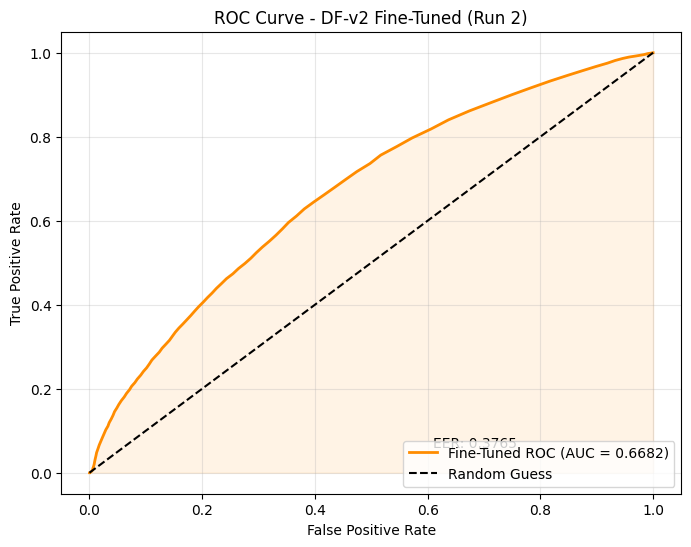

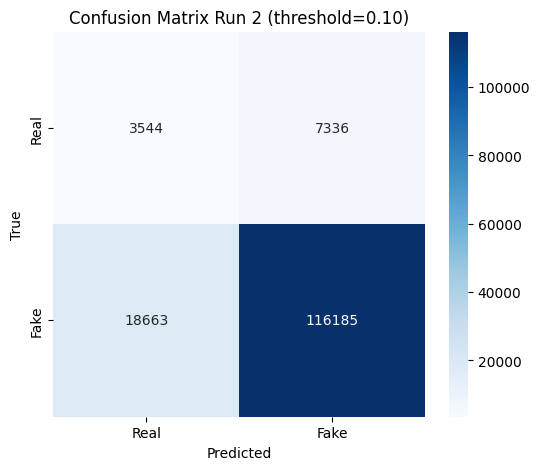

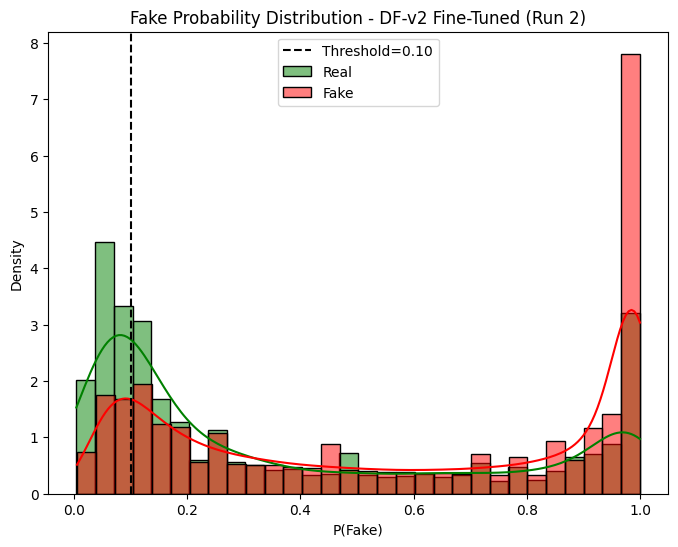

Generating t-SNE Visualization...
Silhouette Score: 0.0337


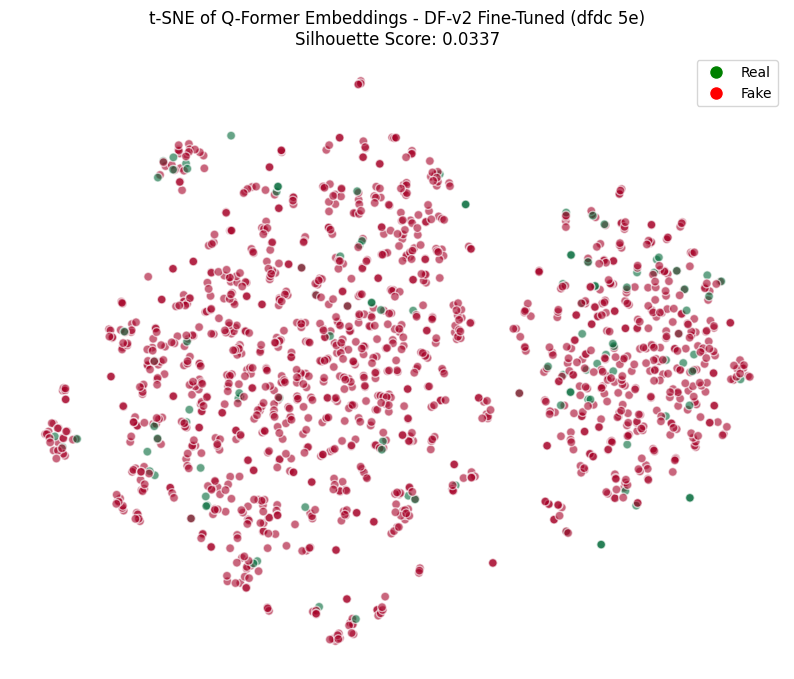

In [ ]:
# --- Advanced Metrics & Visualizations ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Configuration & Paths
# ---------------------------------------------------------
base_results_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_Run2_DFDC_5e'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)

# Set random seed for reproducibility (especially for t-SNE and Bootstrapping)
rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
# We randomly sample our predictions with replacement 1000 times.
# This helps us prove that our AUC score is stable and not just a "lucky" result.
print("Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    # Randomly select indices with replacement
    indices = rng.randint(0, len(all_probs), len(all_probs))

    # Ensure both classes (Real/Fake) are present in the sample
    if len(np.unique(all_labels[indices])) < 2:
        continue

    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

# Sort the results to find the 2.5% and 97.5% percentiles (95% Confidence Interval)
sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve & EER
# ==========================================
# ROC Curve shows the tradeoff between True Positive Rate and False Positive Rate.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

# Calculate Equal Error Rate (EER)
# EER is the point where False Acceptance Rate equals False Rejection Rate.
# In biometric security, a lower EER means a better, more balanced system.
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Fine-Tuned ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add EER text inside the plot
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DF-v2 Fine-Tuned (Run 2)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
# Shows exactly how many images were classified correctly or incorrectly
# based on our calculated 'best_thresh'.
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix Run 2 (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
# Visualizes the model's confidence. We want the green (Real) and red (Fake)
# distributions to be as far apart as possible.
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - DF-v2 Fine-Tuned (Run 2)' )
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("Generating t-SNE Visualization...")
# Sample up to 1500 embeddings to prevent the t-SNE calculation from taking too long
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

# Silhouette Score measures how similar an object is to its own cluster
# compared to other clusters. A score > 0 means the model successfully separated the classes.
sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# t-SNE reduces the high-dimensional Q-Former vectors into 2D points so we can plot them.
embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - DF-v2 Fine-Tuned (dfdc 5e)\nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_finetuned.png'), dpi=300, bbox_inches='tight')

#20. clean model for 3rd evaluation

In [ ]:
import gc
import torch

# 1. Delete the model (and any other heavy variables if needed)
try:
    del model
except NameError:
    pass # In case the model was already deleted

# 2. Force Python's Garbage Collector to run
gc.collect()

# 3. Clear the PyTorch CUDA cache
torch.cuda.empty_cache()

print("Model deleted and GPU/RAM memory cleared.")

Model deleted and GPU/RAM memory cleared.


#21. Initilaize model with fine tuned weights DFDC slow

In [ ]:
# --- Model Initialization + Load Fine-Tuned Weights ---

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- Load Fine-Tuned Q-Former Weights ---
weights_path ="/content/drive/MyDrive/Deepfake_Project/DFDC_Weights_slow/qformer_finetuned_DFDC_slow.pth"

print(f" Loading Q-Former weights from {weights_path}...")
checkpoint = torch.load(weights_path, map_location=device)

# Load the fine tuned weights into the Q-former
model.qformer.load_state_dict(checkpoint)
print(" Q-Former weights loaded successfully!")

# --- Freeze everything for Inference ---
# the model just evaluates
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("Model ready for evaluation!")

 Loading Processor...
 Loading Base Model in bfloat16...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

 Loading Q-Former weights from /content/drive/MyDrive/Deepfake_Project/DFDC_Weights_slow/qformer_finetuned_DFDC_slow.pth...
 Q-Former weights loaded successfully!
Model ready for evaluation!


# 22. dataset loading

In [ ]:
import os
import glob
import json
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

# Custom Dataset class inheriting from PyTorch Dataset
class PreExtractedDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        label_str = row['label']  # Expected: "Yes" (Real) or "No" (Fake)

        # Load image and set the exact prompt from the methodology
        image = Image.open(image_path).convert('RGB')
        prompt = "is this photo real?"

        # Process ONLY the base prompt and image
        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # Pass the plain text label directly to the batch dictionary for evaluation
        inputs['text_label'] = label_str
        return inputs

# --- Paths ---
base_dir = '/content/Balanced_Dataset_V2_RetinaFace'
fake_images_folder = os.path.join(base_dir, 'Fake')
real_images_folder = os.path.join(base_dir, 'Real')

# Load train video IDs to exclude from test set
with open('/content/drive/MyDrive/Deepfake_Project/train_video_ids.json', 'r') as f:
    train_video_ids = set(json.load(f))
print(f"Loaded {len(train_video_ids)} train video IDs to exclude.")

all_paths = []
all_labels = []

# Collect Fake images — exclude train video IDs
if os.path.exists(fake_images_folder):
    fake_paths = glob.glob(os.path.join(fake_images_folder, '**', '*.*'), recursive=True)
    fake_paths = [p for p in fake_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    fake_paths = [p for p in fake_paths if os.path.basename(os.path.dirname(p)) not in train_video_ids]
    all_paths.extend(fake_paths)
    all_labels.extend(["No"] * len(fake_paths))
    print(f"Fake images after filtering: {len(fake_paths)}")
else:
    print(f"Warning: Fake folder not found at {fake_images_folder}")

# Collect Real images — exclude train video IDs
if os.path.exists(real_images_folder):
    real_paths = glob.glob(os.path.join(real_images_folder, '**', '*.*'), recursive=True)
    real_paths = [p for p in real_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    real_paths = [p for p in real_paths if os.path.basename(os.path.dirname(p)) not in train_video_ids]
    all_paths.extend(real_paths)
    all_labels.extend(["Yes"] * len(real_paths))
    print(f"Real images after filtering: {len(real_paths)}")
else:
    print(f"Warning: Real folder not found at {real_images_folder}")

print(f"Total images after filtering train videos: {len(all_paths)}")

if len(all_paths) > 0:
    # Create DataFrame
    test_df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
    print(f"Testing images (Zero-Shot DF-v2): {len(test_df)}")

    # Create Dataset
    test_dataset = PreExtractedDeepfakeDataset(test_df, processor)

    # Calculate optimal workers
    optimal_workers = min(8, multiprocessing.cpu_count())

    # Create DataLoader
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=optimal_workers,
        pin_memory=True,
        prefetch_factor=2
    )
    print("test_dataloader created successfully for Pure Zero-Shot!")
else:
    print("ERROR: No images loaded. Please verify the subfolder names inside /content/Balanced_Dataset_V2_RetinaFace")

Loaded 500 train video IDs to exclude.
Fake images after filtering: 134848
Real images after filtering: 10880
Total images after filtering train videos: 145728
Testing images (Zero-Shot DF-v2): 145728
test_dataloader created successfully for Pure Zero-Shot!


#23. Fine tuned model 3rd Evaluation

In [ ]:
# --- 4. Probabilistic Evaluation Loop + Embeddings Extraction ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

# Put the model in evaluation mode (turns off dropout and freezes weights)
model.eval()

# Lists to store the results of the entire test set
all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = []

# Define the target words we want the model to predict
# "Yes" means Real, "No" means Fake
yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]

# Convert these text words into model token IDs
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids  = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

# Move the token IDs to the GPU
yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("Starting 3rd Fine-Tuned Evaluation on DF-V2 Test Set...")

# Turn off gradient calculation to save memory and speed up inference
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):

        # Move all batch data to the GPU
        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Convert text labels ("Yes"/"No") into numbers (0 for Real, 1 for Fake)
        text_labels = batch['text_label']
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in text_labels])

        # ----------------- 1. Embeddings extraction ----------------------
        # Pass the image through the vision model and then the Q-Former
        # to extract the deep features (embeddings) of the image
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        # Average the tokens to get a single vector per image, then save it
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ------------------ 2. Probabilistic inference -------------------
        # Ask the model to generate only 1 single word (max_new_tokens=1)
        # and tell it to return the raw math scores (output_scores=True)
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        # Get the raw scores (logits) of the very first generated word
        first_token_logits = outputs.scores[0]

        # Extract only the scores belonging to the "Yes" and "No" tokens
        yes_logits = first_token_logits[:, yes_tensor].max(dim=-1).values
        no_logits  = first_token_logits[:, no_tensor].max(dim=-1).values

        # Combine them and convert the raw scores into percentages (0.0 to 1.0) using Softmax
        pair_logits = torch.stack([yes_logits, no_logits], dim=-1)
        pair_probs  = torch.softmax(pair_logits, dim=-1)

        # The probability of being "Fake" is the percentage score of the "No" token
        fake_probability = pair_probs[:, 1]

        # Save batch results to our main lists
        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ------------------------- Metrics & Saving --------------------------------
# Convert lists to NumPy arrays for easy math operations
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)

# Define the folder path and create it if it doesn't exist
save_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_Run3_DFDC_slow'
os.makedirs(save_dir, exist_ok=True)

# Save the raw arrays so we can create graphs later without re-running the model
np.save(f'{save_dir}/finetuned_probs.npy', all_probs)
np.save(f'{save_dir}/finetuned_labels.npy', all_labels)
np.save(f'{save_dir}/finetuned_embeddings.npy', np.array(all_embeddings))
print(f"Saved to: {save_dir}")

# Calculate the main general metric (ROC-AUC)
auc_score = roc_auc_score(all_labels, all_probs)

# Find the absolute best threshold by checking all options from 0.10 to 0.90
thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc = accuracies[best_idx]

# Calculate advanced industry metrics using the best threshold we found
binary_preds = (all_probs >= best_thresh).astype(int)
f1 = f1_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)

# Print the final report
print(f"Optimal Threshold: {best_thresh:.2f} | AUC: {auc_score:.4f} | ACC: {best_acc*100:.2f}% | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

Starting 3rd Fine-Tuned Evaluation on DF-V2 Test Set...


Evaluating: 100%|██████████| 4554/4554 [25:27<00:00,  2.98it/s]


Saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_Run3_DFDC_slow
Optimal Threshold: 0.10 | AUC: 0.5415 | ACC: 31.36% | F1: 0.4276 | Precision: 0.9362 | Recall: 0.2771


#24.Graphs for 3rd Evaluation

Calculating Bootstrap Confidence Intervals (1000 iterations)...
Final ROC-AUC: 0.5415 (95% CI: [0.5354, 0.5467])


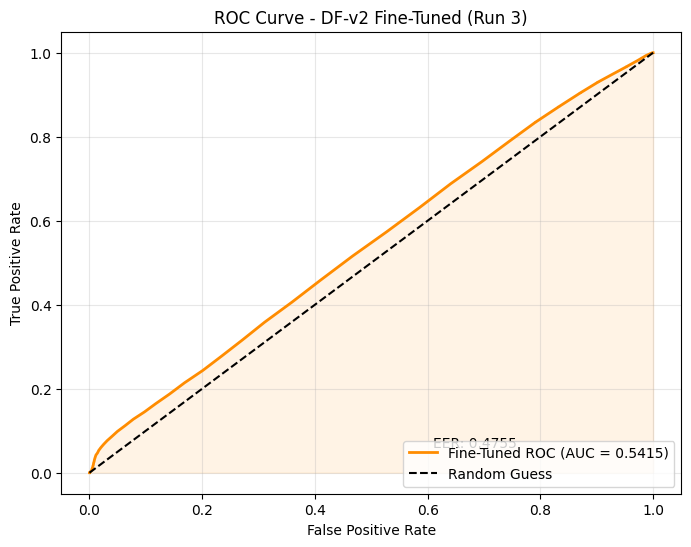

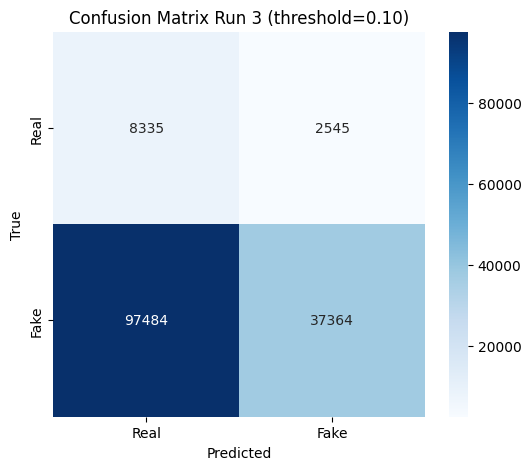

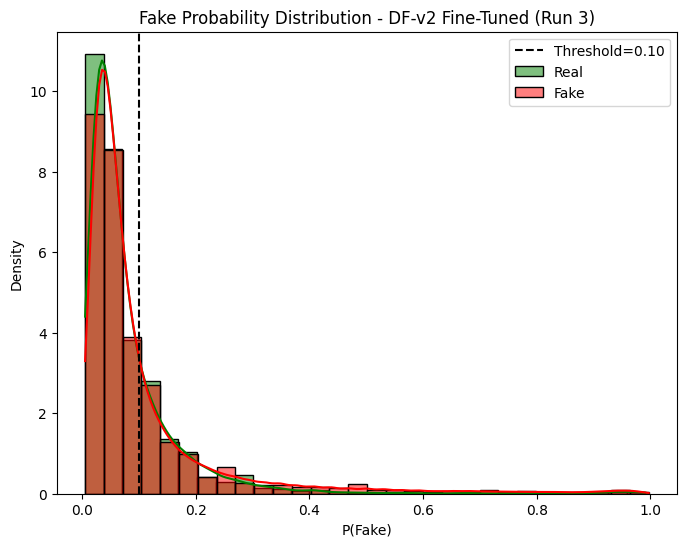

Generating t-SNE Visualization...
Silhouette Score: 0.0299


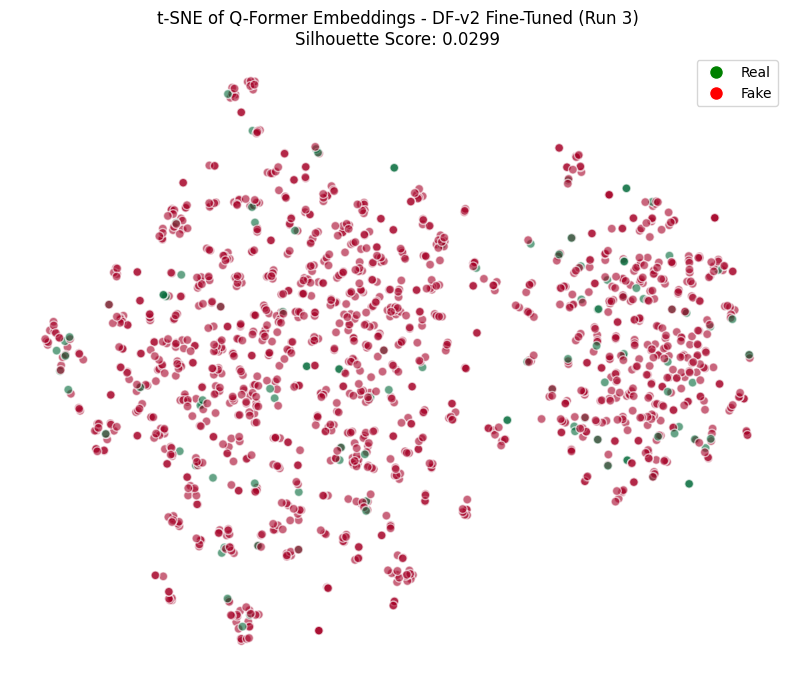

In [ ]:
# --- Advanced Metrics & Visualizations ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Configuration & Paths
# ---------------------------------------------------------
base_results_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_DF-v2_Run3_DFDC_slow'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)

# Set random seed for reproducibility (especially for t-SNE and Bootstrapping)
rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
# We randomly sample our predictions with replacement 1000 times.
# This helps us prove that our AUC score is stable and not just a "lucky" result.
print("Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    # Randomly select indices with replacement
    indices = rng.randint(0, len(all_probs), len(all_probs))

    # Ensure both classes (Real/Fake) are present in the sample
    if len(np.unique(all_labels[indices])) < 2:
        continue

    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

# Sort the results to find the 2.5% and 97.5% percentiles (95% Confidence Interval)
sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve & EER
# ==========================================
# ROC Curve shows the tradeoff between True Positive Rate and False Positive Rate.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

# Calculate Equal Error Rate (EER)
# EER is the point where False Acceptance Rate equals False Rejection Rate.
# In biometric security, a lower EER means a better, more balanced system.
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Fine-Tuned ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add EER text inside the plot
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DF-v2 Fine-Tuned (Run 3)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
# Shows exactly how many images were classified correctly or incorrectly
# based on our calculated 'best_thresh'.
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix Run 3 (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
# Visualizes the model's confidence. We want the green (Real) and red (Fake)
# distributions to be as far apart as possible.
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - DF-v2 Fine-Tuned (Run 3)' )
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("Generating t-SNE Visualization...")
# Sample up to 1500 embeddings to prevent the t-SNE calculation from taking too long
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

# Silhouette Score measures how similar an object is to its own cluster
# compared to other clusters. A score > 0 means the model successfully separated the classes.
sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# t-SNE reduces the high-dimensional Q-Former vectors into 2D points so we can plot them.
embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - DF-v2 Fine-Tuned (Run 3)\nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_finetuned.png'), dpi=300, bbox_inches='tight')